## Access Vessel Bio Optical Pigment Delayed QC data (Parquet)

This notebook demonstrates how to access and visualise **HPLC phytoplankton pigment** data from the
[IMOS Bio-Optical Database of Australian Waters (BODBAW)](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/97b9fe73-ee44-437f-b2ae-5b8613f81042) programme.

### About the data
BODBAW contains discrete water-sample measurements collected at field stations across Australia since the mid-1990s.
HPLC (High-Performance Liquid Chromatography) separates and quantifies individual phytoplankton pigments —
the same pigments that drive ocean colour as seen by satellites such as MODIS-Aqua and Sentinel-3/OLCI.

Key variables include:
- **CPHL_a / DV_CPHL_a** — monovinyl and divinyl chlorophyll-a (primary phytoplankton biomass proxy)
- **DV_CPHL_a_plus_CPHL_a** — total (MV+DV) chlorophyll-a (most widely used)
- **Tot_CPHL** — total chlorophyll (a + b + c), sometimes called TChla
- **PSC** — photosynthetic carotenoids (But-fuco, Fuco, Hex-fuco, Perid) → marker for diatoms, haptophytes
- **PPC** — photoprotective carotenoids (Allo, Diadino, Diato, Zea, α-β-Car)
- **Fuco / But_fuco / Hex_fuco** — fucoxanthin and derivatives → diatom/haptophyte markers
- **Zea** — zeaxanthin → cyanobacteria marker

These pigments are used for **satellite ocean-colour algorithm development and validation**, and for
inferring **phytoplankton community composition** via chemotaxonomy (e.g. CHEMTAX analysis).

📌 Source maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/blob/main/notebooks/vessel_bio_optical_pigment_delayed_qc.ipynb)


In [1]:
dataset_name = "vessel_bio_optical_pigment_delayed_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 495ms
Checked 155 packages in 1ms


✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 16.6 ms, sys: 1.84 ms, total: 18.5 ms
Wall time: 18.2 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 5.29 ms, sys: 1.87 ms, total: 7.16 ms
Wall time: 5.69 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


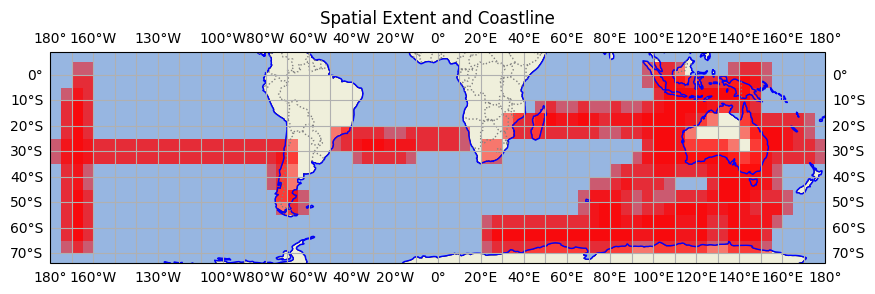

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 48 ms, sys: 21.9 ms, total: 69.8 ms
Wall time: 212 ms


(Timestamp('1985-03-07 00:00:00'), Timestamp('2024-07-31 00:12:00.000000256'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-04-29 11:26:52,678 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_pigment_delayed_qc.parquet


{'timestamp': {'type': 'int64',
  'units': '1',
  'long_name': 'Partition timestamp'},
 'polygon': {'type': 'string',
  'units': '1',
  'long_name': 'Spatial partition polygon'},
 'filename': {'type': 'string',
  'units': '1',
  'long_name': 'Filename of the source file'},
 'TIME': {'type': 'timestamp[ns]',
  'axis': 'T',
  'long_name': 'time',
  'standard_name': 'time'},
 'LATITUDE': {'type': 'float',
  'axis': 'Y',
  'long_name': 'latitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'latitude',
  'units': 'degrees_north',
  'valid_max': 90.0,
  'valid_min': -90.0},
 'LONGITUDE': {'type': 'float',
  'axis': 'X',
  'long_name': 'longitude',
  'reference_datum': 'geographical coordinates, WGS84 projection',
  'standard_name': 'longitude',
  'units': 'degrees_east',
  'valid_max': 180.0,
  'valid_min': -180.0},
 'DEPTH': {'type': 'float',
  'axis': 'Z',
  'long_name': 'depth',
  'positive': 'down',
  'reference_datum': 'sea surface',
  'standar

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
df = aodn_dataset.get_data(#date_start='1994-01-01',
                           #date_end='2023-12-31',
                           lat_min=-40,
                           lat_max=-30,
                           lon_min=110,
                           lon_max=130,
                           )

# Show basic info
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head()


2026-04-29 11:26:55,931 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/vessel_bio_optical_pigment_delayed_qc.parquet


Rows: 1,064  |  Columns: 60
CPU times: user 691 ms, sys: 116 ms, total: 807 ms
Wall time: 3.11 s


,filename,TIME,LATITUDE,LONGITUDE,DEPTH,station_name,CPHL_c3,Mg_DVP,CPHL_c2,CPHL_c1,...,Tot_CPHL_c,Tot_CPHL,PPC,PSC,PSP,Tacc,DP,Tpg,timestamp,polygon
0,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-02-26 13:34:00,-31.857,114.796669,0.0,E,0.000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
1,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-08-17 08:48:00,-31.857,114.796669,0.0,E,0.008,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
2,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-08-17 08:48:00,-31.857,114.796669,30.0,E,0.014,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
3,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-12-17 08:57:00,-31.857,114.796669,0.0,E,0.000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
4,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-12-17 08:57:00,-31.857,114.796669,80.0,E,0.013,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...


In [11]:
df

,filename,TIME,LATITUDE,LONGITUDE,DEPTH,station_name,CPHL_c3,Mg_DVP,CPHL_c2,CPHL_c1,...,Tot_CPHL_c,Tot_CPHL,PPC,PSC,PSP,Tacc,DP,Tpg,timestamp,polygon
0,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-02-26 13:34:00,-31.857000,114.796669,0.0,E,0.000000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
1,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-08-17 08:48:00,-31.857000,114.796669,0.0,E,0.008000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
2,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-08-17 08:48:00,-31.857000,114.796669,30.0,E,0.014000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
3,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-12-17 08:57:00,-31.857000,114.796669,0.0,E,0.000000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
4,IMOS_SRS-OC-BODBAW_X_20020226T133300Z_2Rocks-p...,2002-12-17 08:57:00,-31.857000,114.796669,80.0,E,0.013000,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1009843200,010300000001000000050000000000000000405A400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,IMOS_SRS-OC-BODBAW_X_20000122T041800Z_NB012000...,2000-01-31 06:34:00,-35.510834,120.878670,0.0,22,0.000000,NaN,NaN,NaN,...,0.003679,0.160195,0.119347,0.042623,0.202818,0.173645,0.132334,0.322165,946684800,010300000001000000050000000000000000C05C400000...
1060,IMOS_SRS-OC-BODBAW_X_20000710T213200Z_NB072000...,2000-07-19 10:06:00,-35.500168,124.651169,0.0,23,0.013712,NaN,NaN,NaN,...,0.067961,0.534492,0.072114,0.147968,0.682460,0.363072,0.267158,0.754574,946684800,010300000001000000050000000000000000C05C400000...
1061,IMOS_SRS-OC-BODBAW_X_20000710T213200Z_NB072000...,2000-07-19 22:06:00,-35.496334,121.179001,0.0,24,0.017124,NaN,NaN,NaN,...,0.061321,0.431635,0.066210,0.159406,0.591040,0.331096,0.244268,0.657251,946684800,010300000001000000050000000000000000C05C400000...
1062,IMOS_SRS-OC-BODBAW_X_20000929T204600Z_NB102000...,2000-10-08 06:21:00,-35.489166,124.440170,0.0,20,0.023258,NaN,NaN,NaN,...,0.058391,0.402549,0.133143,0.136085,0.538634,0.359934,0.238595,0.671777,946684800,010300000001000000050000000000000000C05C400000...


In [12]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

## Chlorophyll-a Vertical Profiles

Chlorophyll-a concentration (``DV_CPHL_a_plus_CPHL_a``) is the primary phytoplankton biomass proxy.
Plotting it against depth reveals the **Deep Chlorophyll Maximum (DCM)** — the subsurface layer where
phytoplankton accumulate due to the trade-off between light from above and nutrients from below.

We plot each profile as a line coloured by year so temporal variability is immediately visible.

/tmp/ipykernel_1150804/3974581316.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(years))
/tmp/ipykernel_1150804/3974581316.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sm = plt.cm.ScalarMappable(cmap=cm.get_cmap("tab20", len(years)),


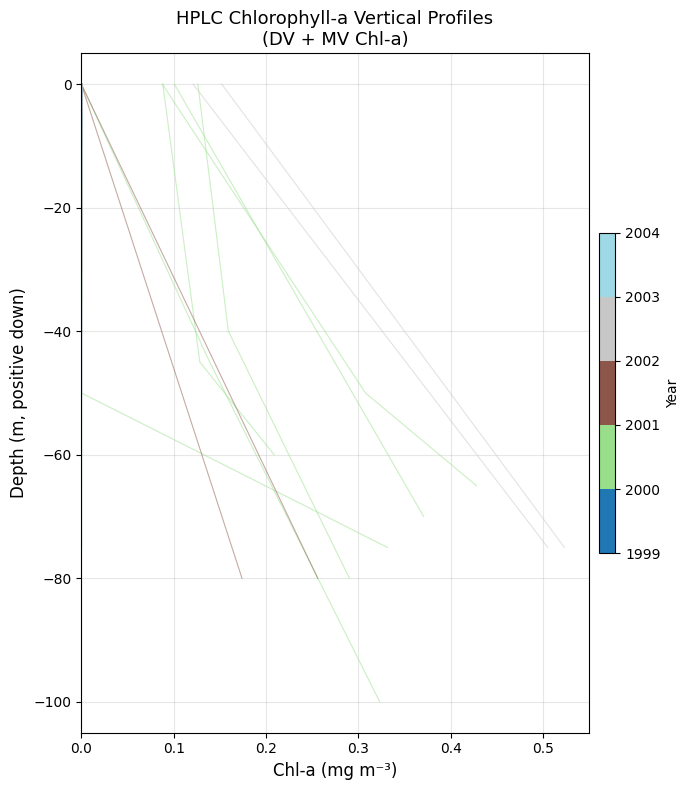

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Use total chlorophyll-a as the primary biomass variable
chl_var = "DV_CPHL_a_plus_CPHL_a"

# Drop rows with missing chlorophyll or depth
df_chl = df[df[chl_var].notna() & df["DEPTH"].notna()].copy()
df_chl["year"] = df_chl["TIME"].dt.year

years = sorted(df_chl["year"].unique())
cmap = cm.get_cmap("tab20", len(years))
year_color = {y: cmap(i) for i, y in enumerate(years)}

fig, ax = plt.subplots(figsize=(7, 8))

for (station, time), grp in df_chl.sort_values("DEPTH").groupby(["station_name", "TIME"]):
    yr = grp["year"].iloc[0]
    ax.plot(grp[chl_var], -grp["DEPTH"],
            color=year_color[yr], alpha=0.5, linewidth=0.8)

# Colour bar for years
sm = plt.cm.ScalarMappable(cmap=cm.get_cmap("tab20", len(years)),
                            norm=plt.Normalize(vmin=min(years), vmax=max(years)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Year", fraction=0.03, pad=0.02)

ax.set_xlabel("Chl-a (mg m⁻³)", fontsize=12)
ax.set_ylabel("Depth (m, positive down)", fontsize=12)
ax.set_title("HPLC Chlorophyll-a Vertical Profiles\n(DV + MV Chl-a)", fontsize=13)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Pigment Composition at the Surface

The relative proportions of accessory pigments reveal the **phytoplankton community structure**.
- **Fuco** (fucoxanthin) → diatoms and dinoflagellates
- **Hex_fuco** → haptophytes (*Phaeocystis*, *Emiliania huxleyi*)
- **But_fuco** → pelagophytes, some haptophytes
- **Perid** → dinoflagellates
- **Zea** → cyanobacteria (*Prochlorococcus*, *Synechococcus*)
- **DV_CPHL_a** (divinyl Chl-a) → *Prochlorococcus*

We show the mean pigment concentrations at the surface (depth ≤ 5 m).

/tmp/ipykernel_1150804/17580522.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)


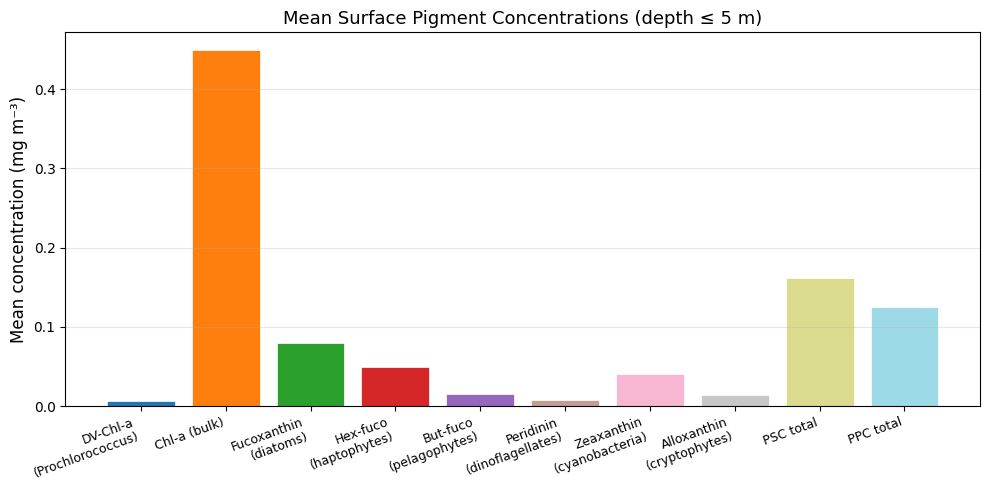

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Surface samples only
df_surf = df[df["DEPTH"] <= 5].copy()

# The most ecologically informative pigments for community composition
pigments = {
    "DV_CPHL_a": "DV-Chl-a\n(Prochlorococcus)",
    "CPHL_a":    "Chl-a (bulk)",
    "Fuco":      "Fucoxanthin\n(diatoms)",
    "Hex_fuco":  "Hex-fuco\n(haptophytes)",
    "But_fuco":  "But-fuco\n(pelagophytes)",
    "Perid":     "Peridinin\n(dinoflagellates)",
    "Zea":       "Zeaxanthin\n(cyanobacteria)",
    "Allo":      "Alloxanthin\n(cryptophytes)",
    "PSC":       "PSC total",
    "PPC":       "PPC total",
}

means = {}
for var, label in pigments.items():
    if var in df_surf.columns:
        m = df_surf[var].dropna()
        if len(m):
            means[label] = m.mean()

labels = list(means.keys())
values = list(means.values())
colors = plt.cm.tab20(np.linspace(0, 1, len(labels)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Mean concentration (mg m⁻³)", fontsize=12)
ax.set_title("Mean Surface Pigment Concentrations (depth ≤ 5 m)", fontsize=13)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Spatial Distribution of Surface Chlorophyll-a

Each dot represents one surface sample coloured by its total Chl-a concentration. This illustrates the spatial distribution of phytoplankton biomass across Australian waters and confirms coverage of the dataset.

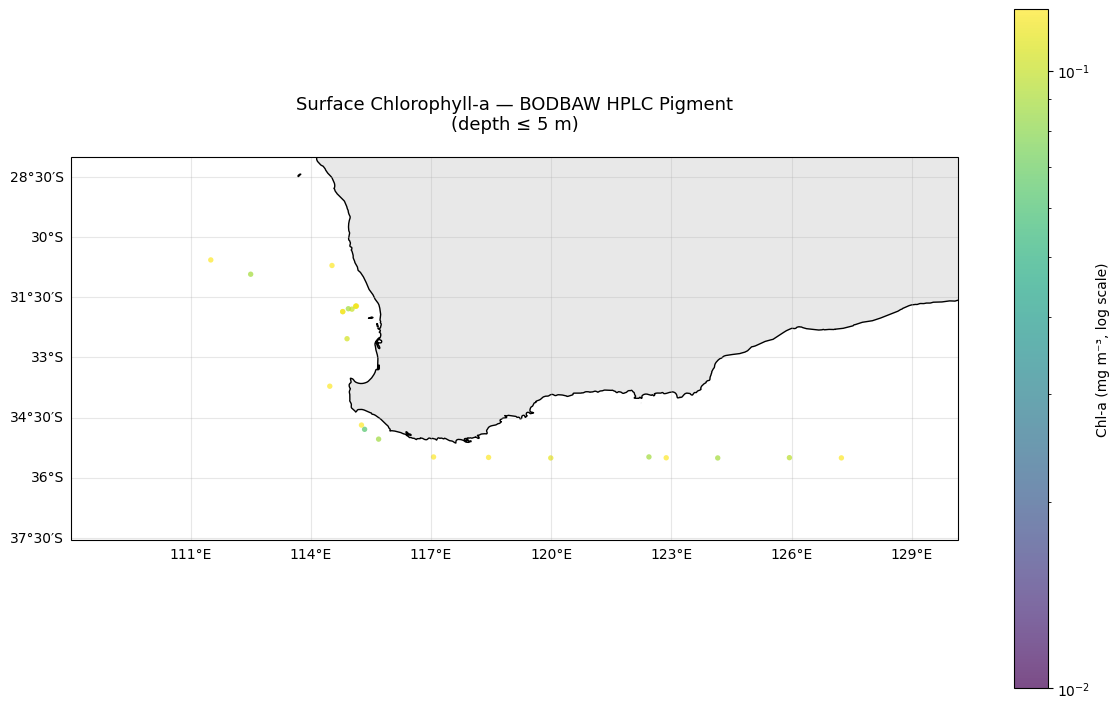

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

chl_surf_var = "DV_CPHL_a_plus_CPHL_a"
df_map = df[df["DEPTH"] <= 5].dropna(subset=[chl_surf_var, "LATITUDE", "LONGITUDE"]).copy()

# Initialize the figure with a PlateCarree projection (standard Lat/Lon)
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Scatter plot - transform=ccrs.PlateCarree() is crucial here
sc = ax.scatter(
    df_map["LONGITUDE"], df_map["LATITUDE"],
    c=df_map[chl_surf_var],
    norm=mcolors.LogNorm(vmin=0.01, vmax=df_map[chl_surf_var].quantile(0.95)),
    cmap="viridis", s=15, alpha=0.7, edgecolors="none",
    transform=ccrs.PlateCarree() 
)

# Set map extent based on data range (optional: adds padding)
ax.set_extent([df_map["LONGITUDE"].min() - 2, df_map["LONGITUDE"].max() + 2, 
               df_map["LATITUDE"].min() - 2, df_map["LATITUDE"].max() + 2])

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(sc, ax=ax, label="Chl-a (mg m⁻³, log scale)", orientation='vertical', shrink=0.7, pad=0.05)

ax.set_title("Surface Chlorophyll-a — BODBAW HPLC Pigment\n(depth ≤ 5 m)", fontsize=13, pad=20)

plt.tight_layout()
plt.show()

## Time Series of Total Chlorophyll-a

Monthly medians of surface total Chl-a show the long-term record and any seasonal or inter-annual signal.

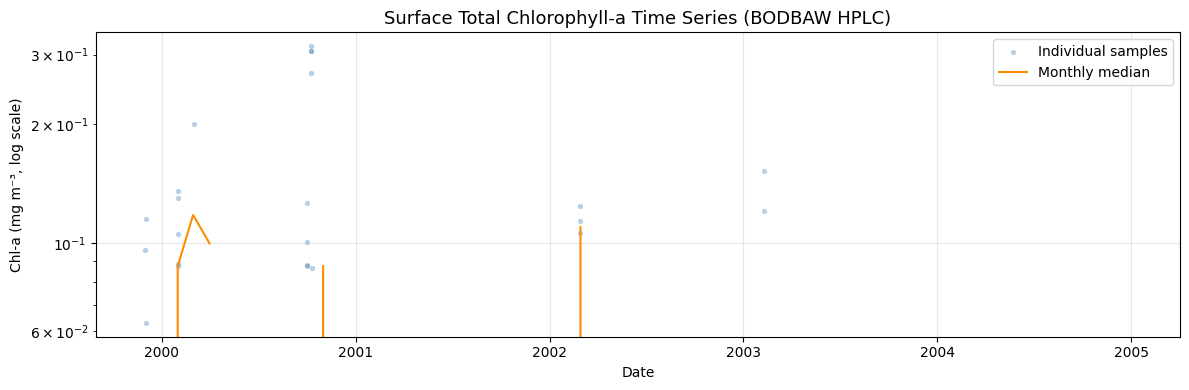

In [16]:
import matplotlib.pyplot as plt

chl_var = "DV_CPHL_a_plus_CPHL_a"
df_ts = df[df["DEPTH"] <= 5].dropna(subset=[chl_var]).copy()
df_ts = df_ts.set_index("TIME").sort_index()

# Monthly median
monthly = df_ts[chl_var].resample("ME").median()
monthly_count = df_ts[chl_var].resample("ME").count()

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(df_ts.index, df_ts[chl_var], s=8, alpha=0.3, color="steelblue", label="Individual samples")
ax.plot(monthly.index, monthly.values, color="darkorange", linewidth=1.5, label="Monthly median")
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Chl-a (mg m⁻³, log scale)")
ax.set_title("Surface Total Chlorophyll-a Time Series (BODBAW HPLC)", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
